In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy.interpolate as interp

In [2]:
# [ADAPTABLE] path to where the drop data are stored (SHOULD END WITH '/002/')
data_path = './002/'

3550


Text(0, 0.5, 'altitude [m]')

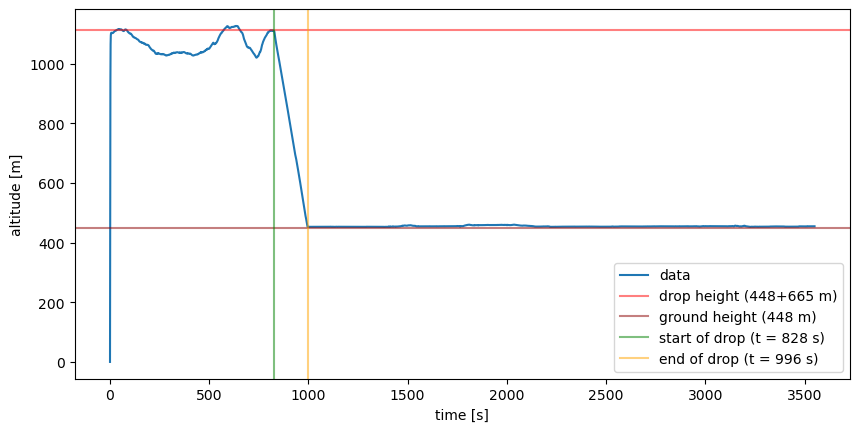

In [3]:
##################################
# altitude                       #
##################################
altitude = np.fromfile(data_path + 'alt.txt', dtype='uint16') / 10 # was stored as dm
N = len(altitude)
print(N)
# altitude was determined and stored at a frequency of 1 Hz, therefore we can get the time of every data point by multiplying by 3550 / N (used in every plot)

# [ADAPTABLE] can be modified to zoom on specific parts of the data 
# (note that the increase from 0 to plane height at the start of the data is due to the time our altitude determination algorithm takes to converge (which started when the drop button was pressed))
t0 = 0
tf = N

time = np.linspace(1, 3550, N)[t0 * N // 3550:tf * N // 3550]
f = plt.figure()
f.set_figwidth(10)
plt.plot(time, altitude[t0 * N // 3550:tf * N // 3550], label='data') # [m], ground height at Dübendorf is 448 m
plt.axhline(448+665, color='r', alpha=0.5, label='drop height (448+665 m)')
plt.axhline(448, color='darkred', alpha=0.5, label='ground height (448 m)')
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('altitude [m]')
# plt.yscale('log')

Text(0, 0.5, 'altitude [m]')

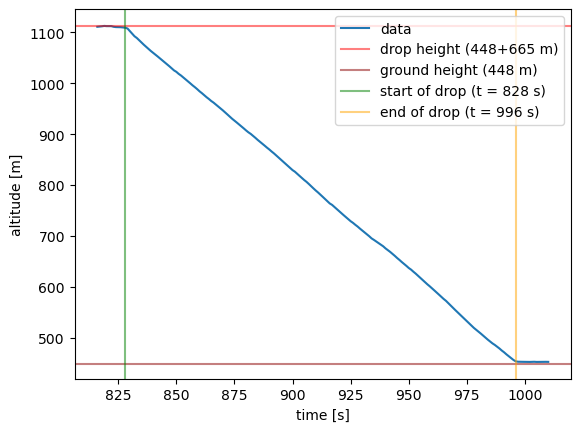

In [4]:
##################################
# zoom on drop part              #
##################################
N = len(altitude)
t0 = 815
tf = 1010
time = np.linspace(1, 3550, N)[t0 * N // 3550:tf * N // 3550]
plt.plot(time, altitude[t0 * N // 3550:tf * N // 3550], label='data') # [m], ground height at Dübendorf is 448 m
plt.axhline(448+665, color='r', alpha=0.5, label='drop height (448+665 m)')
plt.axhline(448, color='darkred', alpha=0.5, label='ground height (448 m)')
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('altitude [m]')

In [5]:
######################################################
# computation of fall duration and vertical velocity #
######################################################
fall_duration = 996 - 828 # [s]
print('fall duration:', fall_duration, 's')
drop_height = 665 # [m]
vertical_speed = drop_height / fall_duration
print('vertical speed:', vertical_speed, 'm/s')

fall duration: 168 s
vertical speed: 3.9583333333333335 m/s


17514


Text(0, 0.5, 'pressure [Pa]')

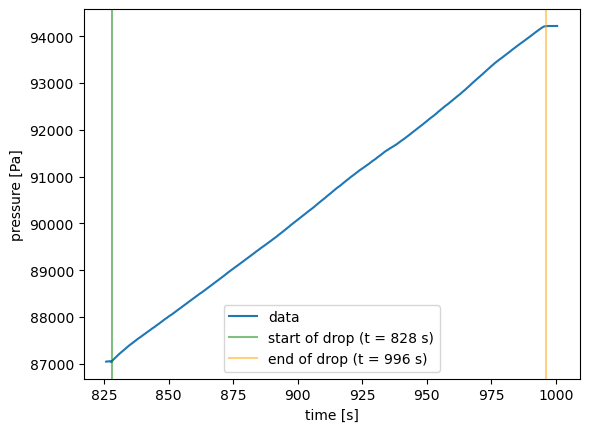

In [6]:
##################################
# pressure                       #
##################################
pressure = np.fromfile(data_path + 'press.txt', dtype='float32')
N = len(pressure)
print(N)

# [ADAPTABLE] can be modified to see the rest of the data
t0 = 825
tf = 1000

time = np.linspace(1, 3550, N)[t0 * N // 3550:tf * N // 3550]
plt.plot(time, pressure[t0 * N // 3550:tf * N // 3550], label='data') # [Pa], ground pressure should be around 93'000-95'000
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('pressure [Pa]')

Text(0.5, 0, 'pressure [Pa]')

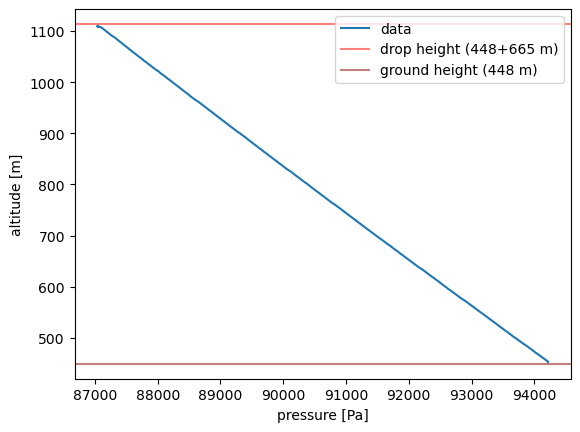

In [7]:
######################################
# pressure as a function of altitude #
######################################
N = len(pressure)
t0 = 825
tf = 1000

data_len = tf * N // 3550 - t0 * N // 3550
altitude_interp = interp.interp1d(np.arange(t0, tf), altitude[t0 : tf], fill_value="extrapolate")
altitude_resized = altitude_interp(np.linspace(t0, tf, data_len))

plt.plot(pressure[t0 * N // 3550:tf * N // 3550], altitude_resized, label='data') # [Pa], ground pressure should be around 93'000-95'000
plt.axhline(448+665, color='r', alpha=0.5, label='drop height (448+665 m)')
plt.axhline(448, color='darkred', alpha=0.5, label='ground height (448 m)')
plt.legend()
plt.ylabel('altitude [m]')
plt.xlabel('pressure [Pa]')

3550


Text(0, 0.5, 'mass concentration [microgram/m^3]')

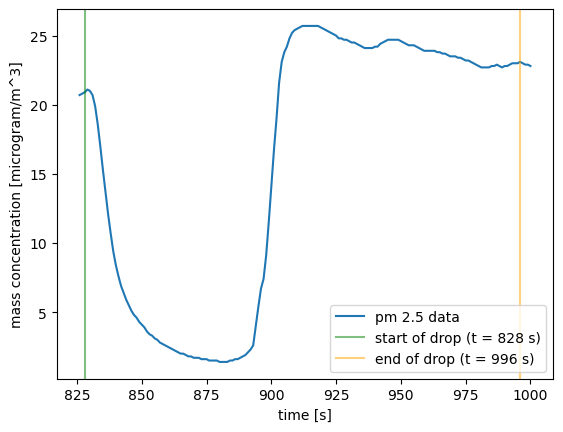

In [8]:
####################
# pm 2.5           #
####################
pm2_5 = np.fromfile(data_path + 'pm2_5.txt', dtype='uint16') / 10 # was stored as microgram/m^3, scaled by 10
N = len(pm2_5)
print(N)

# [ADAPTABLE] can be modified to see the rest of the data
t0 = 825
tf = 1000

time = np.linspace(1, 3550, N)[t0 * N // 3550:tf * N // 3550]
plt.plot(time, pm2_5[t0 * N // 3550:tf * N // 3550], label = 'pm 2.5 data') # values should be in the range 0-50
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('mass concentration [microgram/m^3]')

3550


Text(0, 0.5, 'mass concentration [microgram/m^3]')

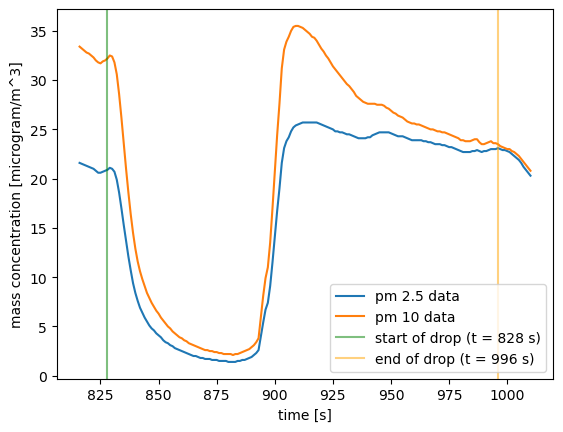

In [9]:
####################
# pm 2.5 and pm 10 #
####################
pm10 = np.fromfile(data_path + 'pm10.txt', dtype='uint16') / 10 # was stored as microgram/m^3, scaled by 10
N = len(pm10)
print(N)

# [ADAPTABLE] can be modified to see the rest of the data
t0 = 815
tf = 1010

time = np.linspace(1, 3550, N)[t0 * N // 3550:tf * N // 3550]
plt.plot(time, pm2_5[t0 * N // 3550:tf * N // 3550], label = "pm 2.5 data")
plt.plot(time, pm10[t0 * N // 3550:tf * N // 3550], label = "pm 10 data") # values should be in the range 0-50
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('mass concentration [microgram/m^3]')

Text(0.5, 0, 'mass concentration [microgram/m^3]')

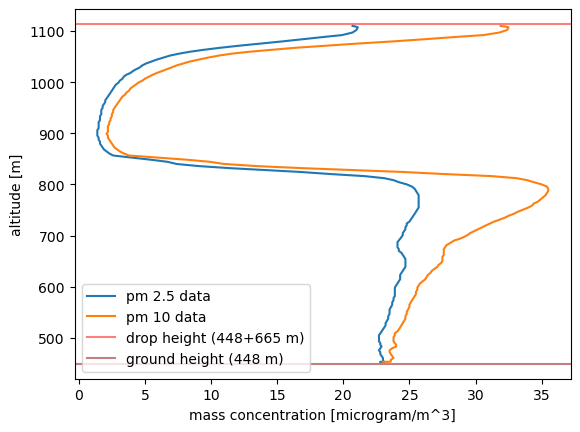

In [10]:
#####################################
# pm data as a function of altitude #
#####################################
N = len(pm10)
t0 = 825
tf = 1000

data_len = tf * N // 3550 - t0 * N // 3550
altitude_interp = interp.interp1d(np.arange(t0, tf), altitude[t0 : tf], fill_value="extrapolate")
altitude_resized = altitude_interp(np.linspace(t0, tf, data_len))

plt.plot(pm2_5[t0 * N // 3550:tf * N // 3550], altitude_resized, label="pm 2.5 data")
plt.plot(pm10[t0 * N // 3550:tf * N // 3550], altitude_resized, label = "pm 10 data") # values should be in the range 0-500
plt.axhline(448+665, color='r', alpha=0.5, label='drop height (448+665 m)')
plt.axhline(448, color='darkred', alpha=0.5, label='ground height (448 m)')

plt.legend()
plt.ylabel('altitude [m]')
plt.xlabel('mass concentration [microgram/m^3]')

*What happened?*

During the analysis of the PM2.5 and PM10 data, we noticed unusually low (almost zero) and inconsistent values during the initial high-speed phase of the flight. This led to the hypothesis that the particulate matter sensor was not able to sample properly while the probe was moving at high velocity.

The most likely explanation is that during high-speed motion:
- The airflow around the sensor inlet was too strong,
- The sensor could not perform proper air sampling,
- Therefore, measurements were unreliable during this phase.

Nonetheless, after an initial "transition" phase of around a minute, the readings do seem to be plausible. According to the [European Environment Agency](https://www.eea.europa.eu/en/analysis/publications/air-quality-status-report-2025/particulate-matter), the **measured 90.4 percentile of PM10 daily concentrations** in Dübendorf was approximately 21 $\mu g/m^3$ in 2023!

17514


Text(0, 0.5, 'temperature [°C]')

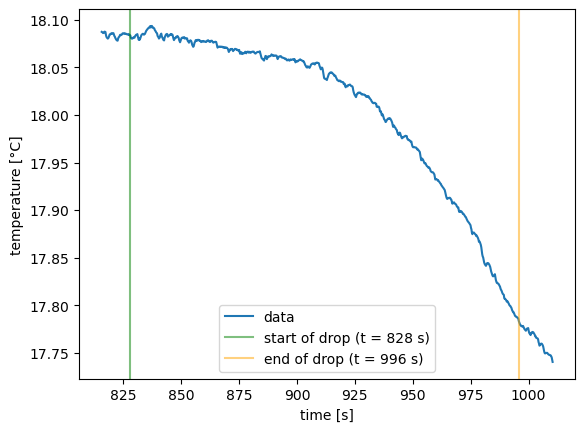

In [11]:
####################
# temperature      #
####################
temperature = np.fromfile(data_path + 'temp.txt', dtype='float32')
N = len(temperature)
print(N)

# [ADAPTABLE] can be modified to see the rest of the data
t0 = 815
tf = 1010

time = np.linspace(1, 3550, N)[t0 * N // 3550:tf * N // 3550]
plt.plot(time, temperature[t0 * N // 3550:tf * N // 3550], label = 'data') # [Celsius degrees]
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('temperature [°C]')

Text(0.5, 0, 'temperature [°C]')

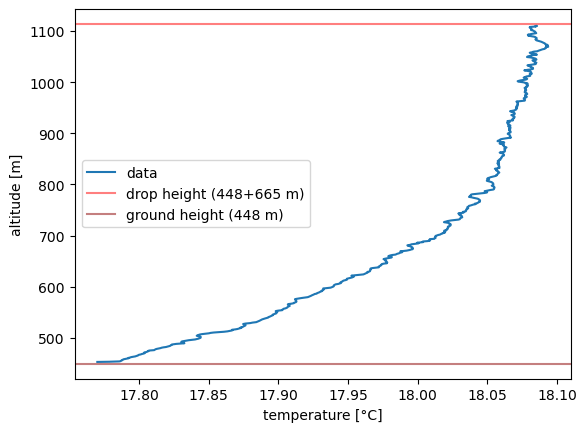

In [12]:
#########################################
# temperature as a function of altitude #
#########################################
N = len(temperature)
t0 = 825
tf = 1000

data_len = tf * N // 3550 - t0 * N // 3550
altitude_interp = interp.interp1d(np.arange(t0, tf), altitude[t0 : tf], fill_value="extrapolate")
altitude_resized = altitude_interp(np.linspace(t0, tf, data_len))

plt.plot(temperature[t0 * N // 3550:tf * N // 3550], altitude_resized, label="data")
plt.axhline(448+665, color='r', alpha=0.5, label='drop height (448+665 m)')
plt.axhline(448, color='darkred', alpha=0.5, label='ground height (448 m)')

plt.legend()
plt.ylabel('altitude [m]')
plt.xlabel('temperature [°C]')

96735


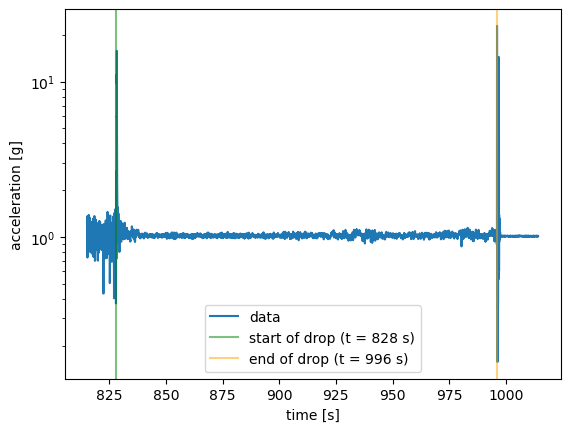

In [13]:
####################
# acceleration     # => one can see the load of the parachute opening and of the landing impact quite clearly
####################
acceleration = np.fromfile(data_path + 'accel.txt', dtype='int16') / 1000 # was stored in milli g
N = len(acceleration)
print(N)

# [ADAPTABLE] can be modified to see the rest of the data
t0 = 795
tf = 1000

time = np.linspace(1, 3450, N)[(t0+43) * N // 3550:(tf+43) * N // 3550][:-1] # the acceleration data is not synced with the bmp data
plt.plot(time, acceleration[t0 * N // 3550:tf * N // 3550], label = 'data')  # [g], should be around 1 when no shock happen and it is not in free fall

plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('acceleration [g]')
plt.yscale('log')

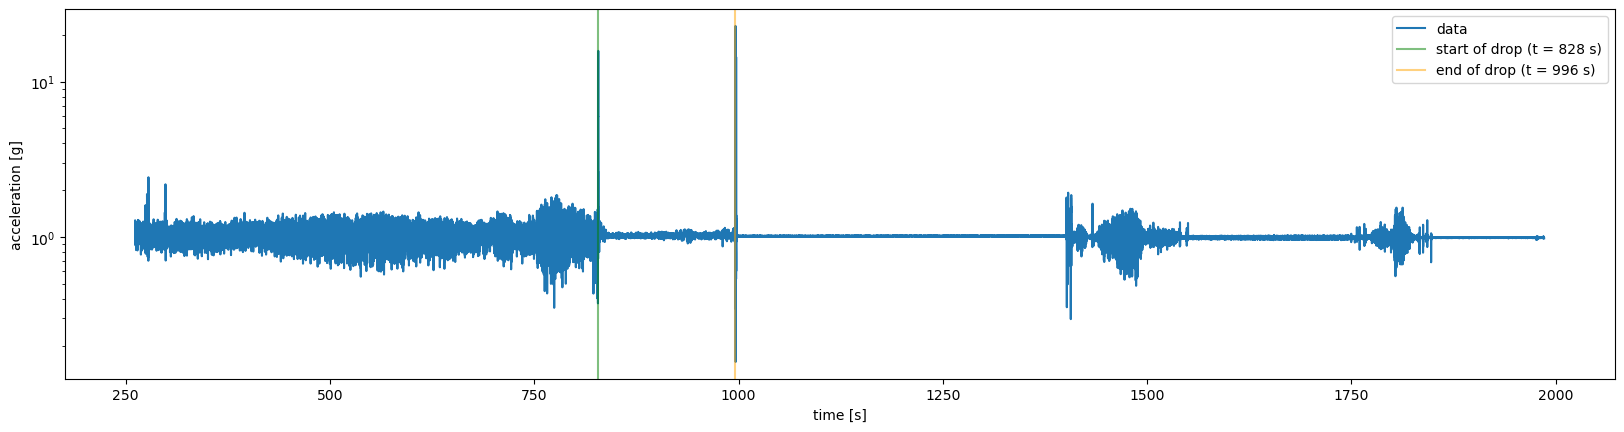

In [14]:
##################################
# acceleration slightly unzoomed # => one can see the vibrations while in the plane and when the probe gets retrieved after end of flight
##################################
N = len(acceleration)

# [ADAPTABLE] can be modified to see the rest of the data
t0 = 225
tf = 2000

time = np.linspace(1, 3450, N)[(t0+43) * N // 3550:(tf+43) * N // 3550][:-1] # the acceleration data is not synced with the bmp data
f = plt.figure()
f.set_figwidth(20)
plt.plot(time, acceleration[t0 * N // 3550:tf * N // 3550], label = 'data')  # [g], should be around 1 when no shock happen and it is not in free fall
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('acceleration [g]')
plt.yscale('log')

136475


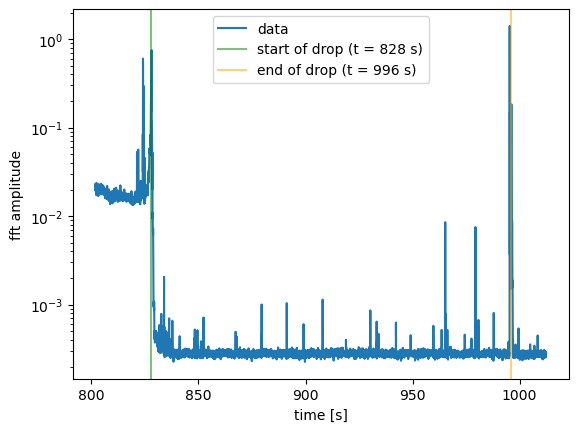

In [15]:
####################################################
# fft (amplitude of integral from 5 kHz to 10 kHz) #
####################################################
audio_samples = np.fromfile(data_path + 'fft.txt', dtype='float32')
print(len(audio_samples))
N = len(audio_samples)

# [ADAPTABLE] can be modified to see the rest of the data
t0 = 815
tf = 1020

time = np.linspace(1, 3650, N)[(t0-36) * N // 3550:(tf-36) * N // 3550] # the fft data is not synced with the bmp data
plt.plot(time, audio_samples[t0 * N // 3550:tf * N // 3550], label = 'data') # noise floor out of the plane is approximately at 0.0003

plt.axvline(828 , color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('fft amplitude')
plt.yscale('log')

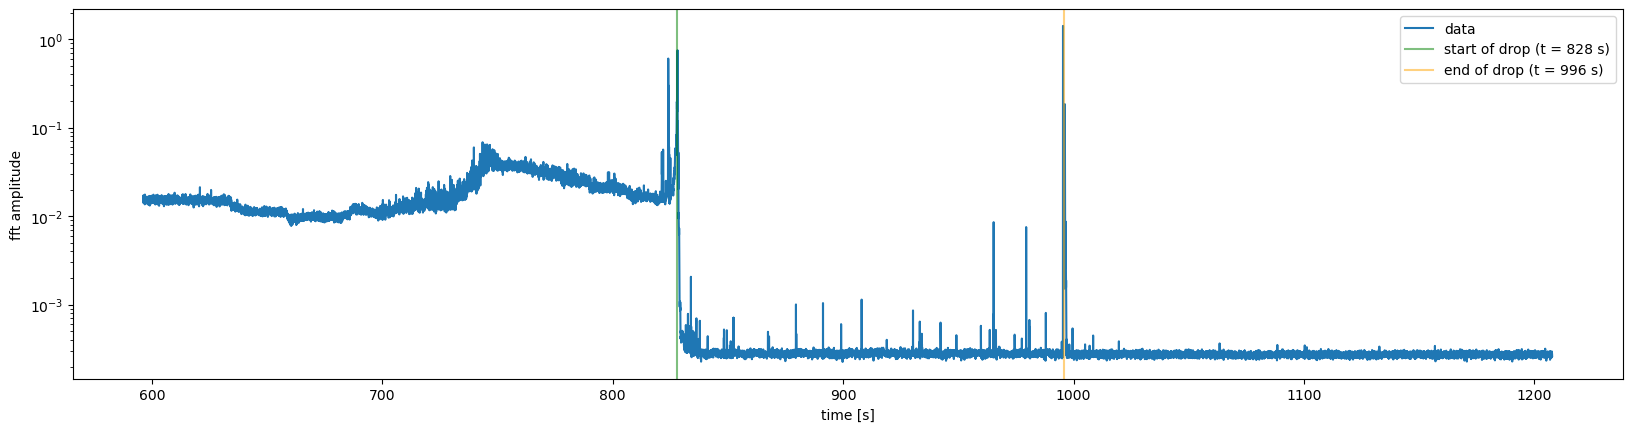

In [16]:
####################################################################################
# fft (amplitude of integral from 5 kHz to 10 kHz) noise floor in plane vs in drop #
####################################################################################
N = len(audio_samples)

t0 = 615
tf = 1210
time = np.linspace(1, 3650, N)[(t0-36) * N // 3550:(tf-36) * N // 3550] # the fft data is not synced with the bmp data
f = plt.figure()
f.set_figwidth(20)
plt.plot(time, audio_samples[t0 * N // 3550:tf * N // 3550], label = 'data') # noise floor out of the plane is approximately at 0.0003

plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('fft amplitude')
plt.yscale('log')

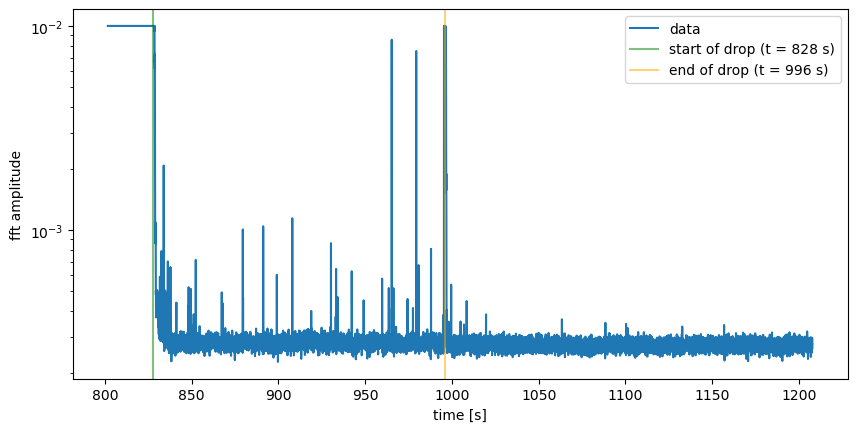

In [17]:
###########################################################################################
# fft (amplitude of integral from 5 kHz to 10 kHz) explosion spikes in drop after landing # with values clamped at a maximum of 1e-2 to better see the reduction in spikes after landing
###########################################################################################
N = len(audio_samples)

t0 = 815
tf = 1210
time = np.linspace(1, 3650, N)[(t0-36) * N // 3550:(tf-36) * N // 3550] # the fft data is not synced with the bmp data
f = plt.figure()
f.set_figwidth(10)
plt.plot(time, np.minimum(audio_samples[t0 * N // 3550:tf * N // 3550], 1e-2), label = 'data') # noise floor out of the plane is approximately at 0.0003

plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('fft amplitude')
plt.yscale('log')

The frequency range integrated by our algorithm was more dampened than anticipated and a threshold of 50 did not detect any explosions. However, looking at the data, one can clearly see signal peaks above the noise floor, indicating that explosions were still detected. We thus set a threshold of 1.5 a posteriori to have them categorised correctly.

32 explosions detected with threshold = 1.5 !


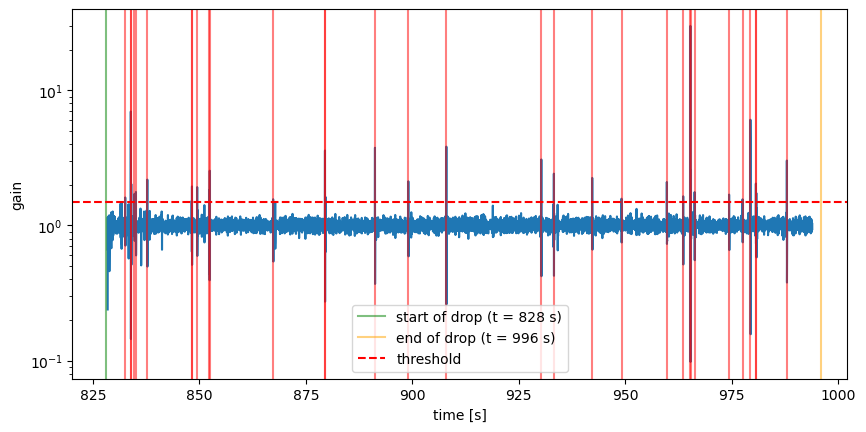

In [18]:
##############################################
# gain (audio_samples[i]/audio_samples[i-1]) # => a post-processing threshold of 1.5 was determined to be optimal in explosion detection, while staying well above the noise floor
##############################################

N = len(audio_samples)

# times adapted to the two "shocks" visible in the data [IF CHANGED, THE VERTICAL LINE INDICATING EXPLOSIONS WON'T MATCH ANYMORE]
t0 = 841
tf = 1002

time = np.linspace(1, 3650, N)[(t0-36) * N // 3550:(tf-36) * N // 3550] # the fft data is not synced with the bmp data
ampls = audio_samples[1 + t0 * N // 3550:tf * N // 3550] / audio_samples[t0 * N // 3550:tf * N // 3550 - 1]
f = plt.figure()
f.set_figwidth(10)
plt.plot(time[:-1], ampls)
c = 0
thresh = 1.5
last = False
explosions = []

for i in range(len(ampls)):
    xi = (((t0 + 0.7 + i / len(ampls) * (tf - t0))-36) * N // 3550)*3650/N
    if ampls[i] > thresh and 829 < xi and xi < 995:
        if not last:
            last = True
            c += 1
            explosions.append(i)
            
            plt.axvline(x=xi, color='r', alpha=0.5)
    else:
        last = False
plt.axvline(828, color='g', label='start of drop (t = 828 s)', alpha=0.5)
plt.axvline(996, color='orange', label='end of drop (t = 996 s)', alpha=0.5)
print(c, 'explosions detected with threshold =', thresh, '!')
plt.axhline(y=thresh, color='r', linestyle='--', label='threshold')
plt.legend()
plt.xlabel('time [s]')
plt.ylabel('gain')
plt.yscale('log')